# MVP v0.2.5.14b: 12-Policy Evaluation with Full OPE Metrics

**Date:** 2026-03-25  
**Builds on:** v0.2.5.14 (action_scale=0.01, rho=0.71 on 6 policies)  

## Goal

Expand v0.2.5.14 from 6 to 12 target policies (spaced from 0% to 90% oracle SR)  
and report full OPE statistics: Spearman rho, log RMSE, Regret@1/3/5, per-policy MSE.

Same setup: v0.2.5.2 diffuser, action_scale=0.01, positive-only guidance.

In [1]:
%matplotlib inline
import sys, os, importlib
import numpy as np
import torch
import torch.nn as nn
import h5py, json, math, time
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

PROJECT_ROOT = Path("/home1/reishuen/latent_sope")
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "src"))
sys.path.insert(0, str(PROJECT_ROOT / "third_party" / "sope"))
sys.path.insert(0, str(PROJECT_ROOT / "third_party" / "robomimic"))

from opelab.core.baselines.diffusion.temporal import TemporalUnet
from opelab.core.baselines.diffusion.diffusion import GaussianDiffusion
from opelab.core.baselines.diffusion.helpers import EMA, apply_conditioning
import robomimic.utils.file_utils as FileUtils
import robomimic.utils.obs_utils as ObsUtils

import latent_sope.robomimic_interface.guidance as _guidance_mod
importlib.reload(_guidance_mod)
from latent_sope.robomimic_interface.checkpoints import (
    load_checkpoint, build_algo_from_checkpoint
)
from latent_sope.robomimic_interface.guidance import RobomimicDiffusionScorer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Paths
CKPT_BASE = PROJECT_ROOT / "third_party/robomimic/diffusion_policy_trained_models"
DEMO_HDF5 = PROJECT_ROOT / "third_party/robomimic/datasets/lift/ph/low_dim_v15.hdf5"
TARGET_ROLLOUT_DIR = PROJECT_ROOT / "rollouts" / "target_policy_50"
DIFFUSION_SAVE_DIR = PROJECT_ROOT / "diffusion_ckpts" / "mvp_v0252_traj_mse"
ORACLE_JSON = PROJECT_ROOT / "results/2026-03-12/oracle_eval_all_checkpoints.json"
OBS_KEYS = ["object", "robot0_eef_pos", "robot0_eef_quat", "robot0_gripper_qpos"]

# Dims
STATE_DIM = 19
ACTION_DIM = 7
TRANSITION_DIM = 26
CUBE_Z_INDEX = 2
LIFT_THRESHOLD = 0.84

# Diffuser config
CHUNK_SIZE = 4
N_DIFFUSION_STEPS = 256
BASE_DIM = 32
DIM_MULTS = (1, 4, 8)
ACTION_WEIGHT = 5.0

# Generation config
NUM_SYNTHETIC = 50
T_GEN = 60
GAMMA = 1.0

# Guidance config
SCORE_TIMESTEP = 5
ACTION_SCALE = 0.01
SIGMOID_SHARPNESS = 150.0

# 12 target policies — spaced across 0%-90% oracle SR
TARGET_POLICIES = [
    {"name": "50demos_epoch10",  "dir": "lift_diffusion_50demos/20260311134204",  "ckpt": "models/model_epoch_10.pth"},
    {"name": "10demos_epoch10",  "dir": "lift_diffusion_10demos/20260311115828",  "ckpt": "models/model_epoch_10.pth"},
    {"name": "200demos_epoch10", "dir": "lift_diffusion_200demos/20260311141036", "ckpt": "models/model_epoch_10.pth"},
    {"name": "200demos_epoch20", "dir": "lift_diffusion_200demos/20260311141036", "ckpt": "models/model_epoch_20.pth"},
    {"name": "100demos_epoch20", "dir": "lift_diffusion_100demos/20260311135551", "ckpt": "models/model_epoch_20.pth"},
    {"name": "test_checkpoint",  "dir": "test/20260309132349",                   "ckpt": "last.pth"},
    {"name": "50demos_epoch20",  "dir": "lift_diffusion_50demos/20260311134204",  "ckpt": "models/model_epoch_20.pth"},
    {"name": "10demos_epoch30",  "dir": "lift_diffusion_10demos/20260311115828",  "ckpt": "models/model_epoch_30.pth"},
    {"name": "100demos_epoch30", "dir": "lift_diffusion_100demos/20260311135551", "ckpt": "models/model_epoch_30.pth"},
    {"name": "50demos_epoch30",  "dir": "lift_diffusion_50demos/20260311134204",  "ckpt": "models/model_epoch_30.pth"},
    {"name": "50demos_epoch40",  "dir": "lift_diffusion_50demos/20260311134204",  "ckpt": "models/model_epoch_40.pth"},
    {"name": "200demos_epoch40", "dir": "lift_diffusion_200demos/20260311141036", "ckpt": "models/model_epoch_40.pth"},
]

print(f"score_timestep={SCORE_TIMESTEP}, action_scale={ACTION_SCALE}")
print(f"{NUM_SYNTHETIC} trajs, T_GEN={T_GEN}")
print(f"{len(TARGET_POLICIES)} target policies to evaluate")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

CLIPTextModelWithProjection LOAD REPORT from: openai/clip-vit-large-patch14
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...23}.self_attn.out_proj.bias   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.v_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.out_proj.weight | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.self_attn.k_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...23}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.encoder.l

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Device: cuda
score_timestep=5, action_scale=0.01
50 trajs, T_GEN=60
12 target policies to evaluate


In [2]:
# ── Reward functions ──

def hard_reward(cube_z):
    return (cube_z > LIFT_THRESHOLD).astype(np.float32)

def sigmoid_reward(cube_z, center=LIFT_THRESHOLD, sharpness=SIGMOID_SHARPNESS):
    return (1.0 / (1.0 + np.exp(-sharpness * (cube_z - center)))).astype(np.float32)

def compute_ope_hard(states, gamma=1.0):
    cube_z = states[:, :, CUBE_Z_INDEX]
    rewards = hard_reward(cube_z)
    gammas = gamma ** np.arange(states.shape[1])
    return (rewards * gammas[None, :]).sum(axis=1)

def compute_ope_sigmoid(states, gamma=1.0):
    cube_z = states[:, :, CUBE_Z_INDEX]
    rewards = sigmoid_reward(cube_z)
    gammas = gamma ** np.arange(states.shape[1])
    return (rewards * gammas[None, :]).sum(axis=1)

def compute_sr_hard(states):
    cube_z = states[:, :, CUBE_Z_INDEX]
    return np.mean([np.any(cube_z[j] > LIFT_THRESHOLD) for j in range(states.shape[0])])

print("Reward/OPE functions defined.")

Reward/OPE functions defined.


In [3]:
# ── Load oracle results ──
with open(ORACLE_JSON, "r") as f:
    oracle_all = json.load(f)

oracle_sr_map = {}
for pol in TARGET_POLICIES:
    name = pol["name"]
    if name == "test_checkpoint":
        with open(CKPT_BASE / "test/20260309132349/oracle_50.json", "r") as f:
            test_oracle = json.load(f)
        oracle_sr_map[name] = float(test_oracle["mean_return"])
    else:
        oracle_sr_map[name] = float(oracle_all[name]["mean_return"])

print("Oracle SR values (sorted):")
for name, sr in sorted(oracle_sr_map.items(), key=lambda x: x[1]):
    print(f"  {name:<22} {sr*100:>5.0f}%")

Oracle SR values (sorted):
  50demos_epoch10            0%
  10demos_epoch10            8%
  200demos_epoch10          18%
  200demos_epoch20          24%
  100demos_epoch20          42%
  test_checkpoint           54%
  50demos_epoch20           60%
  10demos_epoch30           62%
  100demos_epoch30          72%
  50demos_epoch30           82%
  50demos_epoch40           88%
  200demos_epoch40          90%


In [4]:
# ── Load data + normalization ──
all_states_list, all_actions_list = [], []

target_data = []
for path in sorted(TARGET_ROLLOUT_DIR.glob("rollout_*.h5"))[:50]:
    with h5py.File(path, "r") as f:
        latents = f["latents"][:]
        actions = f["actions"][:]
    states = (latents[:, -1, :] if latents.ndim == 3 else latents).astype(np.float32)
    actions = actions.astype(np.float32)
    target_data.append({"states": states, "actions": actions})
    all_states_list.append(states)
    all_actions_list.append(actions)
print(f"Loaded {len(target_data)} target rollouts")

with h5py.File(DEMO_HDF5, "r") as f:
    for dk in sorted(f["data"].keys(), key=lambda x: int(x.split("_")[1])):
        demo = f[f"data/{dk}"]
        states = np.concatenate([demo["obs"][k][:].astype(np.float32) for k in OBS_KEYS], axis=-1)
        actions = demo["actions"][:].astype(np.float32)
        all_states_list.append(states)
        all_actions_list.append(actions)
print(f"Loaded 200 expert demos")

all_states = np.concatenate(all_states_list, axis=0)
all_actions = np.concatenate(all_actions_list, axis=0)
norm_mean = np.concatenate([all_states.mean(0), all_actions.mean(0)]).astype(np.float32)
norm_std = np.maximum(np.concatenate([all_states.std(0), all_actions.std(0)]), 1e-6).astype(np.float32)
norm_mean_t = torch.tensor(norm_mean, device=device)
norm_std_t = torch.tensor(norm_std, device=device)
normalize_fn = lambda x: (x - norm_mean_t) / norm_std_t
unnormalize_fn = lambda x: x * norm_std_t + norm_mean_t

initial_states_t = torch.tensor(
    np.array([ep["states"][0] for ep in target_data[:NUM_SYNTHETIC]]),
    dtype=torch.float32, device=device
)
print(f"Initial states: {initial_states_t.shape}")

Loaded 50 target rollouts


Loaded 200 expert demos
Initial states: torch.Size([50, 19])


In [5]:
# ── Load pre-trained diffuser ──
temporal_model = TemporalUnet(
    horizon=CHUNK_SIZE, transition_dim=TRANSITION_DIM,
    dim=BASE_DIM, dim_mults=DIM_MULTS, attention=False,
).to(device)
diffusion_model = GaussianDiffusion(
    model=temporal_model, horizon=CHUNK_SIZE,
    observation_dim=STATE_DIM, action_dim=ACTION_DIM,
    n_timesteps=N_DIFFUSION_STEPS,
    normalizer=normalize_fn, unnormalizer=unnormalize_fn,
    predict_epsilon=False, loss_type="l2",
    clip_denoised=False, action_weight=ACTION_WEIGHT,
).to(device)
ema = EMA(diffusion_model)
ema.ema_model.load_state_dict(
    torch.load(DIFFUSION_SAVE_DIR / "diffusion_model_ema.pt", map_location=device)
)
print(f"Loaded EMA diffuser from {DIFFUSION_SAVE_DIR}")

[ models/temporal ] Channel dimensions: [(26, 32), (32, 128), (128, 256)]
[(26, 32), (32, 128), (128, 256)]


/home1/reishuen/latent_sope/third_party/sope/opelab/core/baselines/diffusion/diffusion.py:314: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  betas * np.sqrt(alphas_cumprod_prev) / (1. - alphas_cumprod))


Loaded EMA diffuser from /home1/reishuen/latent_sope/diffusion_ckpts/mvp_v0252_traj_mse


In [6]:
# ── Trajectory generator ──

def generate_trajectories(
    diffusion_model, initial_states,
    normalize_fn, unnormalize_fn,
    state_dim, action_dim, chunk_size, t_gen, device,
    target_scorer=None,
    action_scale=0.0, normalize_grad=True,
):
    guided = (target_scorer is not None and action_scale > 0)
    B = initial_states.shape[0]
    td = state_dim + action_dim
    n_ts = diffusion_model.n_timesteps

    pad = torch.cat([initial_states, torch.zeros(B, action_dim, device=device)], 1)
    cond_init = normalize_fn(pad)[:, :state_dim]
    all_traj = torch.zeros(B, t_gen, td, device=device)
    conditions = {0: cond_init}
    total = 0

    while total < t_gen:
        x = torch.randn(B, chunk_size, td, device=device)
        x = apply_conditioning(x, conditions, state_dim)

        for t_d in reversed(range(n_ts)):
            t_t = torch.full((B,), t_d, device=device, dtype=torch.long)
            with torch.no_grad():
                mm, _, mlv = diffusion_model.p_mean_variance(x=x, t=t_t)
                ms = torch.exp(0.5 * mlv)

            if guided:
                mm = unnormalize_fn(mm)
                sc = mm[:, :, :state_dim]
                ac = mm[:, :, state_dim:]
                tg = target_scorer.grad_log_prob_chunk(sc, ac)
                if normalize_grad:
                    tg = tg / (tg.norm(dim=-1, keepdim=True) + 1e-6)
                guide = torch.zeros_like(mm)
                guide[:, :, state_dim:] = tg
                mm = mm + action_scale * guide
                mm = normalize_fn(mm)
                mm = apply_conditioning(mm, conditions, state_dim)
                mm = unnormalize_fn(mm)
                mm = normalize_fn(mm)

            noise = torch.randn_like(x)
            x = mm + (1 - (t_d == 0) * 1.0) * ms * noise
            x = apply_conditioning(x, conditions, state_dim)

        chunk_u = unnormalize_fn(x)
        n_store = min(chunk_size - 1, t_gen - total)
        all_traj[:, total:total+n_store] = chunk_u[:, 1:1+n_store]
        total += n_store

        if total < t_gen:
            last_state_norm = x[:, -1, :state_dim]
            conditions = {0: last_state_norm}

    return all_traj.cpu().numpy()

print("Generator ready.")

Generator ready.


In [7]:
# ── Generate unguided trajectories ──
print("Generating unguided trajectories...")
np.random.seed(42)
torch.manual_seed(42)

t0 = time.time()
unguided_trajs = generate_trajectories(
    diffusion_model=ema.ema_model,
    initial_states=initial_states_t,
    normalize_fn=normalize_fn, unnormalize_fn=unnormalize_fn,
    state_dim=STATE_DIM, action_dim=ACTION_DIM,
    chunk_size=CHUNK_SIZE, t_gen=T_GEN, device=device,
)
unguided_time = time.time() - t0

unguided_states = unguided_trajs[:, :, :STATE_DIM]
unguided_sr = compute_sr_hard(unguided_states)
unguided_returns_hard = compute_ope_hard(unguided_states, GAMMA)
unguided_returns_sigmoid = compute_ope_sigmoid(unguided_states, GAMMA)

print(f"Unguided: hard SR={unguided_sr*100:.0f}%, "
      f"hard OPE={unguided_returns_hard.mean():.3f}, "
      f"sigmoid OPE={unguided_returns_sigmoid.mean():.3f}, "
      f"{unguided_time:.0f}s")

Generating unguided trajectories...


Unguided: hard SR=60%, hard OPE=5.020, sigmoid OPE=7.992, 32s


In [8]:
# ── Loop over 12 target policies ──
results = {}
t0_all = time.time()

for i, pol in enumerate(TARGET_POLICIES):
    name = pol["name"]
    oracle_sr = oracle_sr_map[name]
    run_dir = CKPT_BASE / pol["dir"]
    ckpt_file = pol["ckpt"]

    print(f"\n[{i+1}/{len(TARGET_POLICIES)}] {name} (oracle={oracle_sr*100:.0f}%)")

    print(f"  Loading checkpoint...", end=" ", flush=True)
    t0 = time.time()
    ckpt = load_checkpoint(run_dir, ckpt_path=Path(ckpt_file))
    target_algo = build_algo_from_checkpoint(ckpt, device=str(device))
    target_scorer = RobomimicDiffusionScorer(
        target_algo, device=str(device), score_timestep=SCORE_TIMESTEP, obs_keys=OBS_KEYS
    )
    load_time = time.time() - t0
    print(f"{load_time:.0f}s")

    print(f"  Generating guided trajectories...", end=" ", flush=True)
    np.random.seed(42)
    torch.manual_seed(42)
    t0 = time.time()
    guided_trajs = generate_trajectories(
        diffusion_model=ema.ema_model,
        initial_states=initial_states_t,
        normalize_fn=normalize_fn, unnormalize_fn=unnormalize_fn,
        state_dim=STATE_DIM, action_dim=ACTION_DIM,
        chunk_size=CHUNK_SIZE, t_gen=T_GEN, device=device,
        target_scorer=target_scorer,
        action_scale=ACTION_SCALE, normalize_grad=True,
    )
    gen_time = time.time() - t0

    guided_states = guided_trajs[:, :, :STATE_DIM]
    guided_sr = compute_sr_hard(guided_states)
    guided_returns_hard = compute_ope_hard(guided_states, GAMMA)
    guided_returns_sigmoid = compute_ope_sigmoid(guided_states, GAMMA)

    results[name] = {
        "oracle_sr": oracle_sr,
        "guided_sr_hard": guided_sr,
        "guided_ope_hard": float(guided_returns_hard.mean()),
        "guided_ope_sigmoid": float(guided_returns_sigmoid.mean()),
        "guided_returns_hard": guided_returns_hard,
        "guided_returns_sigmoid": guided_returns_sigmoid,
        "guided_states": guided_states,
    }

    print(f"{gen_time:.0f}s — SR={guided_sr*100:.0f}%, "
          f"hard={guided_returns_hard.mean():.3f}, "
          f"sigmoid={guided_returns_sigmoid.mean():.3f} "
          f"(oracle={oracle_sr*100:.0f}%)")

total_time = time.time() - t0_all
print(f"\nTotal: {total_time:.0f}s ({total_time/60:.1f} min)")


[1/12] 50demos_epoch10 (oracle=0%)
  Loading checkpoint... 


============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['robot0_eef_quat', 'robot0_eef_pos', 'object', 'robot0_gripper_qpos']
using obs modality: rgb with keys: []
using obs modality: depth with keys: []
using obs modality: scan with keys: []


number of parameters: 6.576359e+07


[16:49:33] INFO     build_algo_from_checkpoint took 0.49 seconds to execute                           ]8;id=494092;file:///home1/reishuen/latent_sope/src/latent_sope/utils/common.py\common.py]8;;\:]8;id=163318;file:///home1/reishuen/latent_sope/src/latent_sope/utils/common.py#137\137]8;;\

47s
  Generating guided trajectories... 

...


============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['robot0_eef_quat', 'robot0_eef_pos', 'object', 'robot0_gripper_qpos']
using obs modality: rgb with keys: []
using obs modality: depth with keys: []
using obs modality: scan with keys: []


number of parameters: 6.576359e+07


[17:06:25] INFO     build_algo_from_checkpoint took 0.42 seconds to execute                           ]8;id=560999;file:///home1/reishuen/latent_sope/src/latent_sope/utils/common.py\common.py]8;;\:]8;id=551352;file:///home1/reishuen/latent_sope/src/latent_sope/utils/common.py#137\137]8;;\

1s
  Generating guided trajectories... 

69s — SR=68%, hard=4.400, sigmoid=7.462 (oracle=90%)

Total: 1129s (18.8 min)


In [9]:
# ── Compute full OPE metrics ──

# Sort policies by oracle SR for consistent display
sorted_names = sorted([p["name"] for p in TARGET_POLICIES], key=lambda n: oracle_sr_map[n])

oracle_srs = np.array([oracle_sr_map[n] for n in sorted_names])
guided_hard = np.array([results[n]["guided_ope_hard"] for n in sorted_names])
guided_sigm = np.array([results[n]["guided_ope_sigmoid"] for n in sorted_names])
unguided_hard_val = float(unguided_returns_hard.mean())
unguided_sigm_val = float(unguided_returns_sigmoid.mean())

# --- Spearman rho ---
rho_g_hard, p_g_hard = stats.spearmanr(oracle_srs, guided_hard)
rho_g_sigm, p_g_sigm = stats.spearmanr(oracle_srs, guided_sigm)

# --- RMSE (in oracle-SR scale) ---
# Normalize OPE estimates to [0,1] scale for fair comparison with oracle SR
# Use per-step mean: OPE_hard / T_GEN gives per-step reward ≈ SR
guided_hard_norm = guided_hard / T_GEN  # per-step reward ≈ success rate
guided_sigm_norm = guided_sigm / T_GEN
unguided_hard_norm = unguided_hard_val / T_GEN
unguided_sigm_norm = unguided_sigm_val / T_GEN

rmse_g_hard = np.sqrt(np.mean((oracle_srs - guided_hard_norm) ** 2))
rmse_g_sigm = np.sqrt(np.mean((oracle_srs - guided_sigm_norm) ** 2))
rmse_u_hard = np.sqrt(np.mean((oracle_srs - unguided_hard_norm) ** 2))
rmse_u_sigm = np.sqrt(np.mean((oracle_srs - unguided_sigm_norm) ** 2))

# --- Log RMSE ---
eps = 1e-6
log_rmse_g_hard = np.sqrt(np.mean((np.log(oracle_srs + eps) - np.log(guided_hard_norm + eps)) ** 2))
log_rmse_g_sigm = np.sqrt(np.mean((np.log(oracle_srs + eps) - np.log(guided_sigm_norm + eps)) ** 2))
log_rmse_u_hard = np.sqrt(np.mean((np.log(oracle_srs + eps) - np.log(unguided_hard_norm + eps)) ** 2))
log_rmse_u_sigm = np.sqrt(np.mean((np.log(oracle_srs + eps) - np.log(unguided_sigm_norm + eps)) ** 2))

# --- Regret@k ---
def regret_at_k(oracle_vals, ope_vals, k):
    """Regret@k: mean(top-k true) - mean(true values of top-k by estimate)."""
    true_topk_idx = np.argsort(oracle_vals)[-k:]
    est_topk_idx = np.argsort(ope_vals)[-k:]
    return float(oracle_vals[true_topk_idx].mean() - oracle_vals[est_topk_idx].mean())

regret_g_hard = {k: regret_at_k(oracle_srs, guided_hard, k) for k in [1, 3, 5]}
regret_g_sigm = {k: regret_at_k(oracle_srs, guided_sigm, k) for k in [1, 3, 5]}
regret_u_hard = {k: regret_at_k(oracle_srs, np.full_like(oracle_srs, unguided_hard_norm), k) for k in [1, 3, 5]}

# --- Per-policy MSE ---
per_policy_mse_hard = (oracle_srs - guided_hard_norm) ** 2
per_policy_mse_sigm = (oracle_srs - guided_sigm_norm) ** 2

print("Metrics computed.")

Metrics computed.


In [10]:
# ── Summary table ──
print("=" * 120)
print(f"v0.2.5.14b: 12-POLICY EVALUATION — action_scale={ACTION_SCALE}, positive-only")
print(f"Diffuser: v0.2.5.2 (200 demos + 50 rollouts)")
print("=" * 120)

print(f"\n{'Policy':<22} {'Oracle':>7} {'G-Hard':>8} {'G-Sigm':>8} {'G-SR':>6} "
      f"{'MSE(H)':>8} {'MSE(S)':>8}")
print("-" * 75)
for name in sorted_names:
    r = results[name]
    idx = sorted_names.index(name)
    print(f"{name:<22} {r['oracle_sr']*100:>6.0f}% {r['guided_ope_hard']:>7.3f} "
          f"{r['guided_ope_sigmoid']:>7.3f} {r['guided_sr_hard']*100:>5.0f}% "
          f"{per_policy_mse_hard[idx]:>7.4f} {per_policy_mse_sigm[idx]:>7.4f}")

print(f"\n{'='*120}")
print(f"AGGREGATE METRICS")
print(f"{'='*120}")
print(f"\n{'Metric':<30} {'Guided Hard':>14} {'Guided Sigmoid':>16} {'Unguided Hard':>16}")
print("-" * 80)
print(f"{'Spearman rho':<30} {rho_g_hard:>+14.4f} {rho_g_sigm:>+16.4f} {'N/A (flat)':>16}")
print(f"{'Spearman p-value':<30} {p_g_hard:>14.4f} {p_g_sigm:>16.4f} {'':>16}")
print(f"{'RMSE':<30} {rmse_g_hard:>14.4f} {rmse_g_sigm:>16.4f} {rmse_u_hard:>16.4f}")
print(f"{'Log RMSE':<30} {log_rmse_g_hard:>14.4f} {log_rmse_g_sigm:>16.4f} {log_rmse_u_hard:>16.4f}")
print(f"{'Regret@1':<30} {regret_g_hard[1]:>14.4f} {regret_g_sigm[1]:>16.4f} {'':>16}")
print(f"{'Regret@3':<30} {regret_g_hard[3]:>14.4f} {regret_g_sigm[3]:>16.4f} {'':>16}")
print(f"{'Regret@5':<30} {regret_g_hard[5]:>14.4f} {regret_g_sigm[5]:>16.4f} {'':>16}")
print(f"{'Mean per-policy MSE':<30} {per_policy_mse_hard.mean():>14.4f} {per_policy_mse_sigm.mean():>16.4f} {'':>16}")

v0.2.5.14b: 12-POLICY EVALUATION — action_scale=0.01, positive-only
Diffuser: v0.2.5.2 (200 demos + 50 rollouts)

Policy                  Oracle   G-Hard   G-Sigm   G-SR   MSE(H)   MSE(S)
---------------------------------------------------------------------------
50demos_epoch10             0%   3.060   6.347    50%  0.0026  0.0112
10demos_epoch10             8%   2.960   6.238    56%  0.0009  0.0006
200demos_epoch10           18%   4.820   7.947    74%  0.0099  0.0023
200demos_epoch20           24%   4.580   7.546    66%  0.0268  0.0131
100demos_epoch20           42%   4.220   7.276    56%  0.1223  0.0892
test_checkpoint            54%   3.340   6.538    50%  0.2346  0.1858
50demos_epoch20            60%   4.020   7.133    62%  0.2841  0.2315
10demos_epoch30            62%   4.360   7.315    60%  0.2996  0.2481
100demos_epoch30           72%   3.860   7.005    52%  0.4299  0.3639
50demos_epoch30            82%   3.860   6.990    62%  0.5710  0.4949
50demos_epoch40            88%   4.0

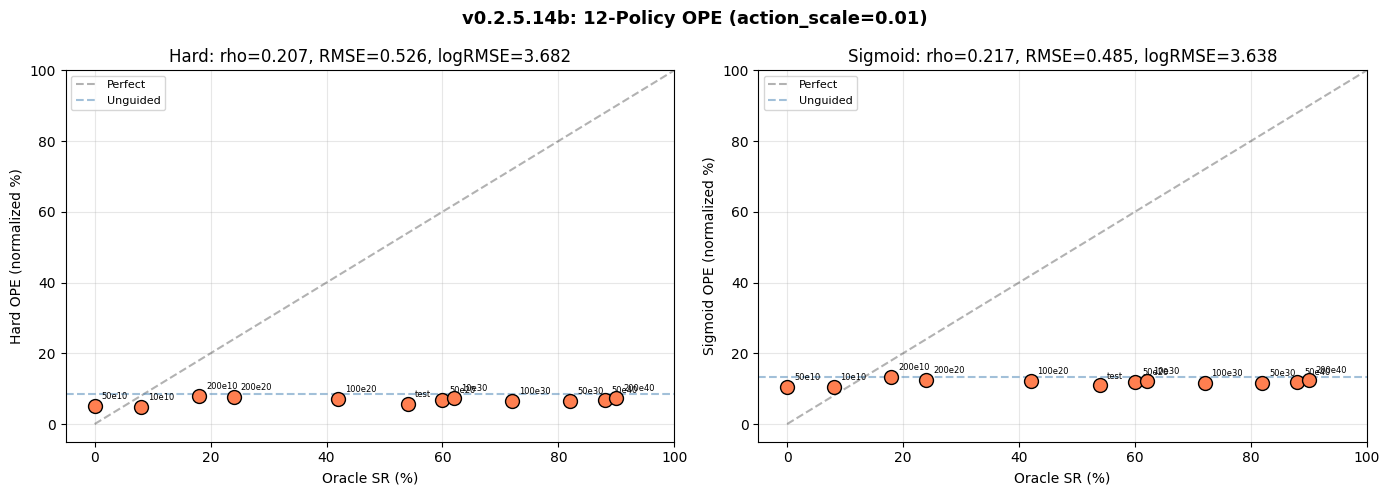

In [11]:
# ── Figure 1: Oracle vs Guided OPE scatter ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, opes_norm, reward_type, rho, rmse_val, log_rmse_val in [
    (axes[0], guided_hard_norm, "Hard", rho_g_hard, rmse_g_hard, log_rmse_g_hard),
    (axes[1], guided_sigm_norm, "Sigmoid", rho_g_sigm, rmse_g_sigm, log_rmse_g_sigm),
]:
    ax.scatter(oracle_srs * 100, opes_norm * 100, s=100, c="coral", edgecolor="black", zorder=5)
    for j, n in enumerate(sorted_names):
        label = n.replace("demos_epoch", "e").replace("test_checkpoint", "test")
        ax.annotate(label, (oracle_srs[j]*100, opes_norm[j]*100),
                    textcoords="offset points", xytext=(5, 5), fontsize=6)
    ax.plot([0, 100], [0, 100], 'k--', alpha=0.3, label="Perfect")
    ax.axhline(y=(unguided_hard_norm if reward_type=="Hard" else unguided_sigm_norm)*100,
               color="steelblue", ls="--", alpha=0.5, label="Unguided")
    ax.set_xlabel("Oracle SR (%)")
    ax.set_ylabel(f"{reward_type} OPE (normalized %)")
    ax.set_title(f"{reward_type}: rho={rho:.3f}, RMSE={rmse_val:.3f}, logRMSE={log_rmse_val:.3f}")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-5, 100)
    ax.set_ylim(-5, 100)

fig.suptitle(f"v0.2.5.14b: 12-Policy OPE (action_scale={ACTION_SCALE})",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

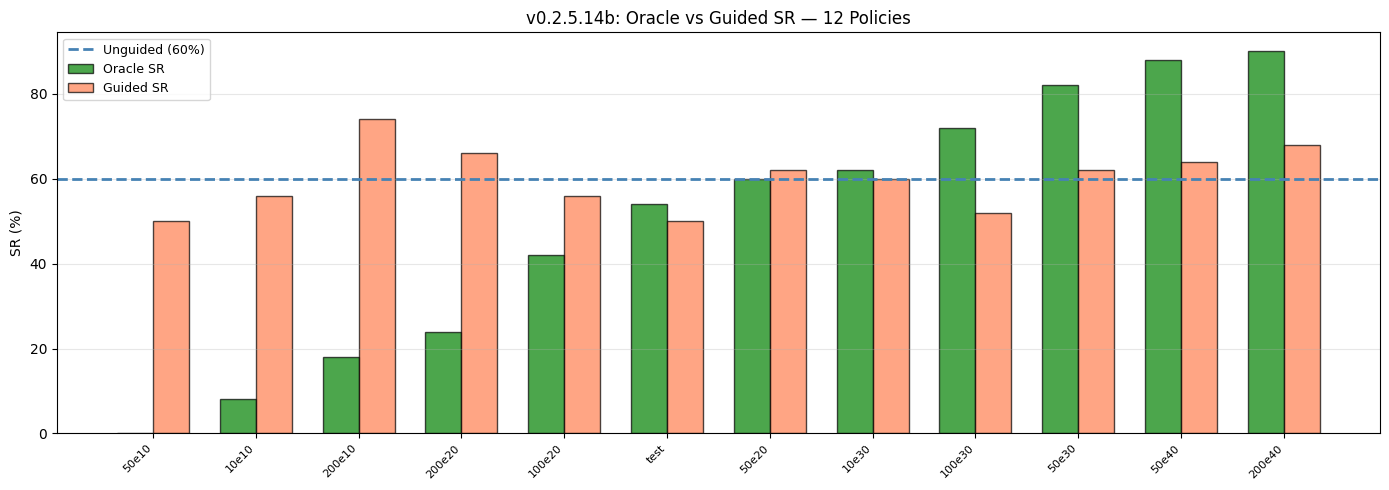

In [12]:
# ── Figure 2: Bar chart — Oracle vs Guided SR ──
fig, ax = plt.subplots(1, 1, figsize=(14, 5))
x = np.arange(len(sorted_names))
w = 0.35
labels = [n.replace("demos_epoch", "e").replace("test_checkpoint", "test") for n in sorted_names]

ax.bar(x - w/2, oracle_srs * 100, w, color="green", edgecolor="black", alpha=0.7, label="Oracle SR")
guided_srs = [results[n]["guided_sr_hard"] * 100 for n in sorted_names]
ax.bar(x + w/2, guided_srs, w, color="coral", edgecolor="black", alpha=0.7, label="Guided SR")
ax.axhline(unguided_sr * 100, color="steelblue", ls="--", lw=2,
           label=f"Unguided ({unguided_sr*100:.0f}%)")

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("SR (%)")
ax.set_title(f"v0.2.5.14b: Oracle vs Guided SR — 12 Policies")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

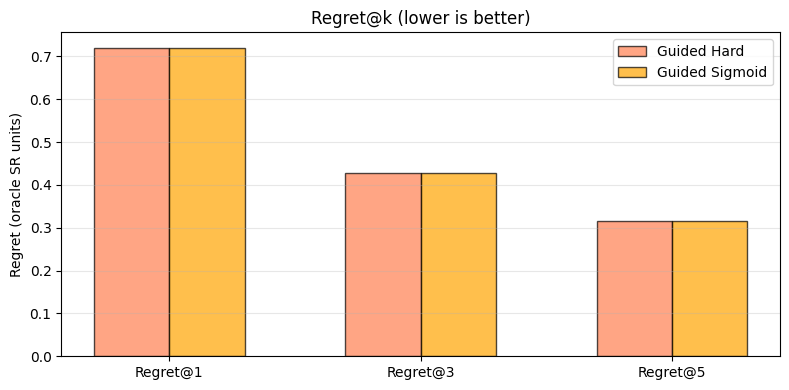

In [13]:
# ── Figure 3: Regret@k bar chart ──
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
k_vals = [1, 3, 5]
x = np.arange(len(k_vals))
w = 0.3

ax.bar(x - w/2, [regret_g_hard[k] for k in k_vals], w,
       color="coral", edgecolor="black", alpha=0.7, label="Guided Hard")
ax.bar(x + w/2, [regret_g_sigm[k] for k in k_vals], w,
       color="orange", edgecolor="black", alpha=0.7, label="Guided Sigmoid")

ax.set_xticks(x)
ax.set_xticklabels([f"Regret@{k}" for k in k_vals])
ax.set_ylabel("Regret (oracle SR units)")
ax.set_title("Regret@k (lower is better)")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

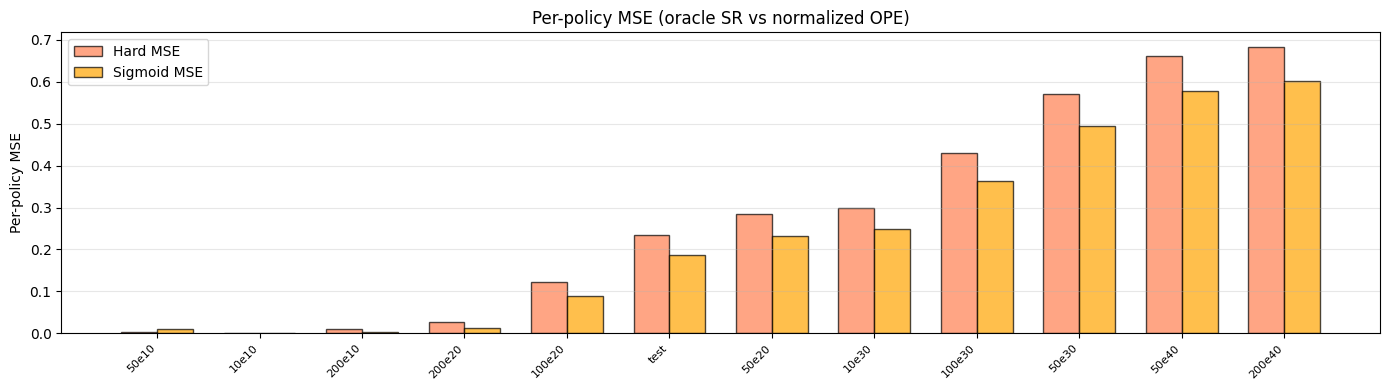

In [14]:
# ── Figure 4: Per-policy MSE ──
fig, ax = plt.subplots(1, 1, figsize=(14, 4))
x = np.arange(len(sorted_names))
w = 0.35
labels = [n.replace("demos_epoch", "e").replace("test_checkpoint", "test") for n in sorted_names]

ax.bar(x - w/2, per_policy_mse_hard, w, color="coral", edgecolor="black", alpha=0.7, label="Hard MSE")
ax.bar(x + w/2, per_policy_mse_sigm, w, color="orange", edgecolor="black", alpha=0.7, label="Sigmoid MSE")

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Per-policy MSE")
ax.set_title("Per-policy MSE (oracle SR vs normalized OPE)")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

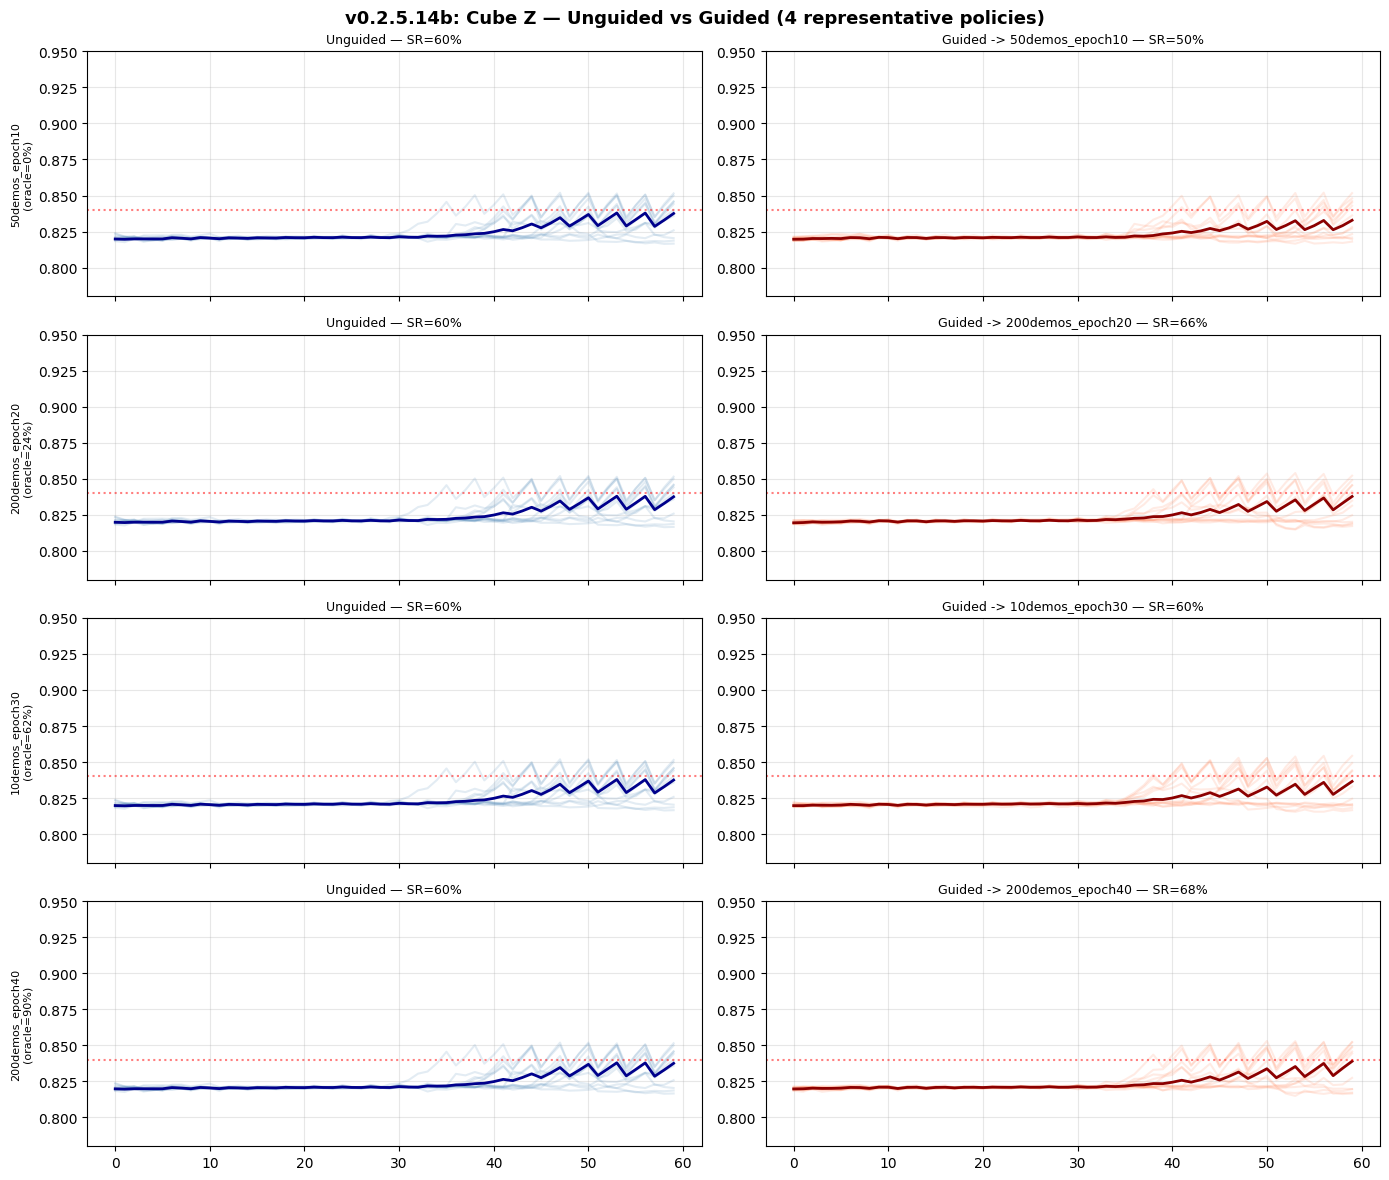

In [15]:
# ── Figure 5: Cube z trajectories (subset: 4 policies across range) ──
show_policies = [sorted_names[0], sorted_names[3], sorted_names[7], sorted_names[11]]
fig, axes = plt.subplots(len(show_policies), 2, figsize=(14, 3 * len(show_policies)), sharex=True)

for row, name in enumerate(show_policies):
    r = results[name]
    osr = r["oracle_sr"]
    gs = r["guided_states"]

    ax = axes[row, 0]
    for j in range(min(12, NUM_SYNTHETIC)):
        ax.plot(unguided_states[j, :, CUBE_Z_INDEX], color="steelblue", alpha=0.15)
    ax.plot(unguided_states[:, :, CUBE_Z_INDEX].mean(0), color="darkblue", lw=2)
    ax.axhline(y=LIFT_THRESHOLD, color="red", ls=":", alpha=0.5)
    ax.set_ylim([0.78, 0.95])
    ax.set_title(f"Unguided — SR={unguided_sr*100:.0f}%", fontsize=9)
    ax.set_ylabel(f"{name}\n(oracle={osr*100:.0f}%)", fontsize=8)
    ax.grid(True, alpha=0.3)

    ax = axes[row, 1]
    for j in range(min(12, NUM_SYNTHETIC)):
        ax.plot(gs[j, :, CUBE_Z_INDEX], color="coral", alpha=0.15)
    ax.plot(gs[:, :, CUBE_Z_INDEX].mean(0), color="darkred", lw=2)
    ax.axhline(y=LIFT_THRESHOLD, color="red", ls=":", alpha=0.5)
    ax.set_ylim([0.78, 0.95])
    ax.set_title(f"Guided -> {name} — SR={r['guided_sr_hard']*100:.0f}%", fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle(f"v0.2.5.14b: Cube Z — Unguided vs Guided (4 representative policies)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()